# Entregab de Laboratiorio 1

Miembros:
- Joseph Anderson Cose Rojas


## Parte 1


@Josue debe ir colocando tu código aqui

## Parte 2
Ejecutar con EXPLAIN ANALYZE y mostrar el resultado

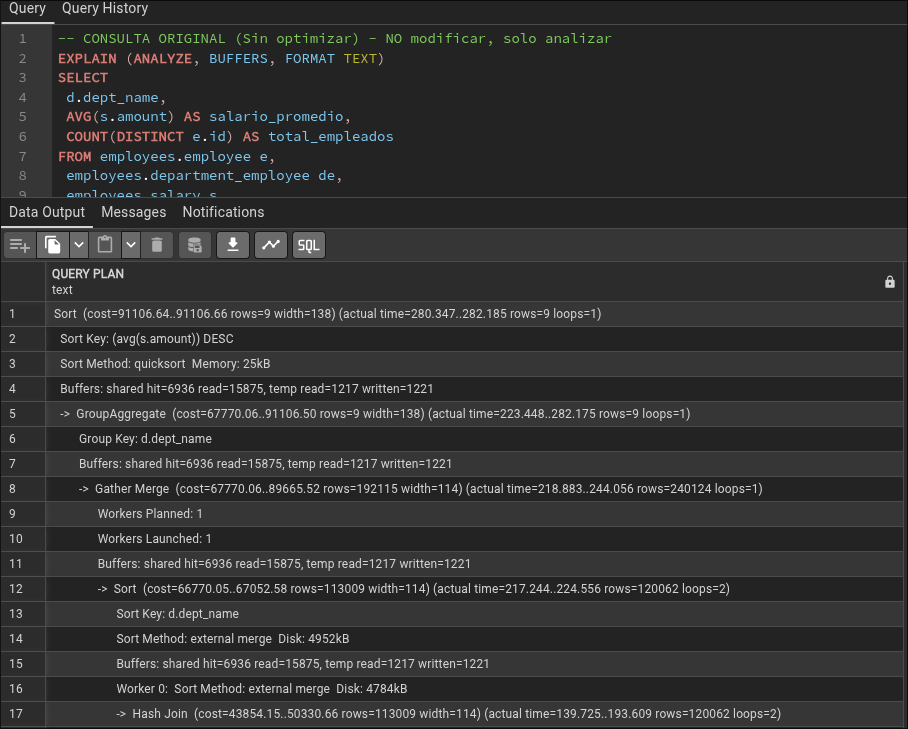
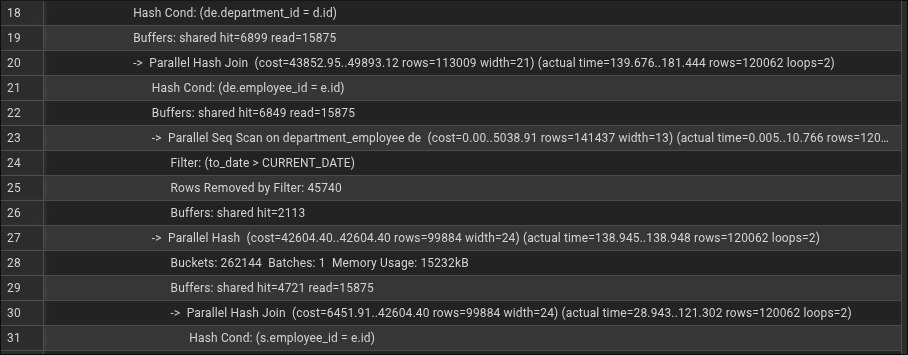
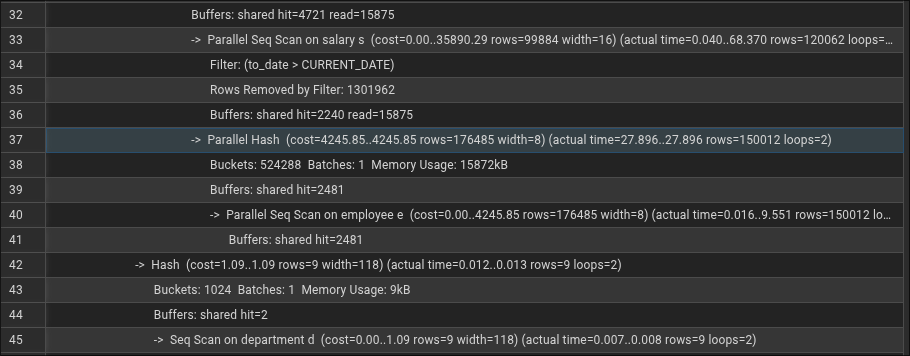
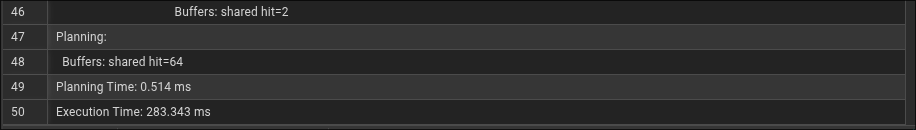

**Preguntas 2.1.1**
1. **¿Qué problemas identifica en el diseño de la consulta?**
    - Usa comas en el FROM en vez de usar JOIN ... ON para separar la lógica de unión de los filtros (WHERE) .
2. **¿Qué tipo de join eligió el planificador (Hash Join, Nested Loop, Merge Join)? ¿Por qué?**
    - Como se visualiza en las imagenes se usa Hash Join. Porque las tablas employee, salary, department_employee son grandes. Crear una tabla Hash en memoria de la tabla más pequeña y compararla con la grande es más eficiente que hacer un bucle anidado cuando no hay índices que ayuden a ir directamente a los datos.
3. **¿Cuántos nodos aparecen en el plan? Identifiquen el nodo más costoso.**
    - Como se visuzaliza contamos con 11 nodos en la consulta, entre ellos el nodo más costoso fue el de '->  Parallel Seq Scan on salary s' porque lee 120,062 filas en el cual al siguiente paso tiene un filtro que remueve 1,301,962 filas.
4. **¿Cuál es el tiempo total de ejecución ( actual time )?**
    - El timeo total de ejecución fue de: 283.343 ms.
5. **¿Hay algún Seq Scan ? ¿Sobre qué tabla? ¿Es esperable dado el tamaño de la tabla?**
    - Hay Seq Scan en las 4 tablas: department_employee, salary, employee y department. En la tabla department solo hay 9 filas lo cual es esperable, al igual que la tablas de employee que cuanta con 300,000 que son aceptables. Pero en la tabla salary es ineficiente porque tiene un filtro to_date > CURRENT_DATE. Sin un índice en to_date hace que lea todo para luego descartar los datos antiguos que normalmente son el 90% de los datos e igual en la tabla department_employee.

## Parte 3

### Pregunta 3.2

Se presenta el código a manera de respuesta:

```sql
CREATE OR REPLACE FUNCTION employees.fn_validar_salario()
RETURNS TRIGGER AS $$
BEGIN
    IF NEW.amount < 30000 THEN
        RAISE EXCEPTION 'Salario menor al mínimo permitido';
    END IF;
    RETURN NEW;
END;
$$ LANGUAGE plpgsql;

CREATE TRIGGER trg_validar_salario
BEFORE INSERT ON employees.salary
FOR EACH ROW
EXECUTE FUNCTION employees.fn_validar_salario();
```


### Pregunta 3.3
```sql
CREATE OR REPLACE PROCEDURE employees.sp_ajustar_salario(
    p_employee_id BIGINT,
    p_nuevo_monto BIGINT,
    p_anio INT
)
LANGUAGE plpgsql
AS $$
DECLARE
    v_old_amount BIGINT;
    v_table TEXT;
BEGIN
    -- 1. Obtener salario vigente
    SELECT amount INTO v_old_amount
    FROM employees.salary
    WHERE employee_id = p_employee_id
      AND to_date > CURRENT_DATE; --validación especifica

    -- 2. Cerrar registro de salario vigente (to_date = CURRENT_DATE)
    UPDATE employees.salary
    SET to_date = CURRENT_DATE
    WHERE employee_id = p_employee_id
      AND to_date > CURRENT_DATE;

    -- 3. Insertar nuevo salario (el trigger valida el monto)
    INSERT INTO employees.salary(employee_id, amount, from_date, to_date)
    VALUES (p_employee_id, p_nuevo_monto, CURRENT_DATE, '9999-01-01');

    -- 4. Insertar auditoria, generar dinámicamente el nombre de la tabla según el año
    v_table := 'audit_salary_' || p_anio;

EXECUTE format(
    'INSERT INTO %I.%I (employee_id, old_amount, new_amount) VALUES ($1,$2,$3)',
    'employees', v_table
)
USING p_employee_id, v_old_amount, p_nuevo_monto;

END;
$$;
```


#### Resultado de las pruebas Testing de la función y procedimiento

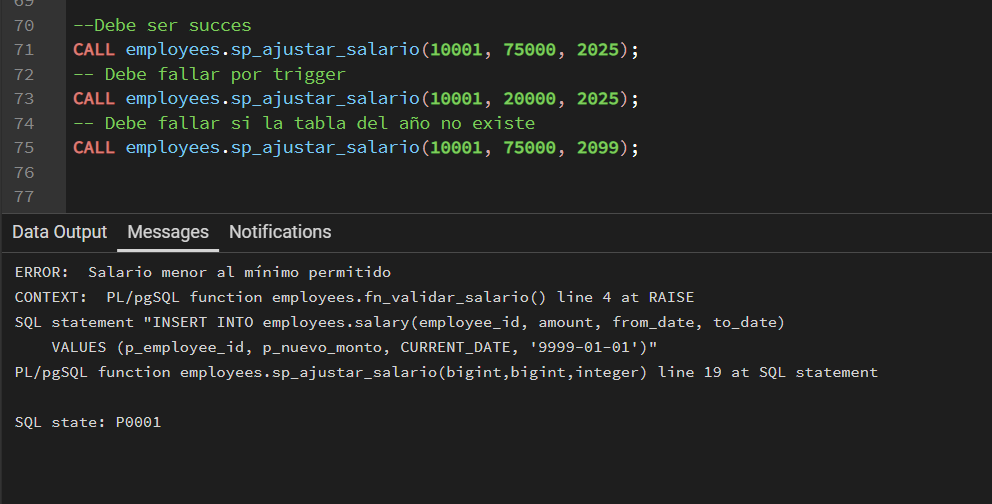
 > Aqui el tercer comando no se ejecutó aún por el error inicial del segundo

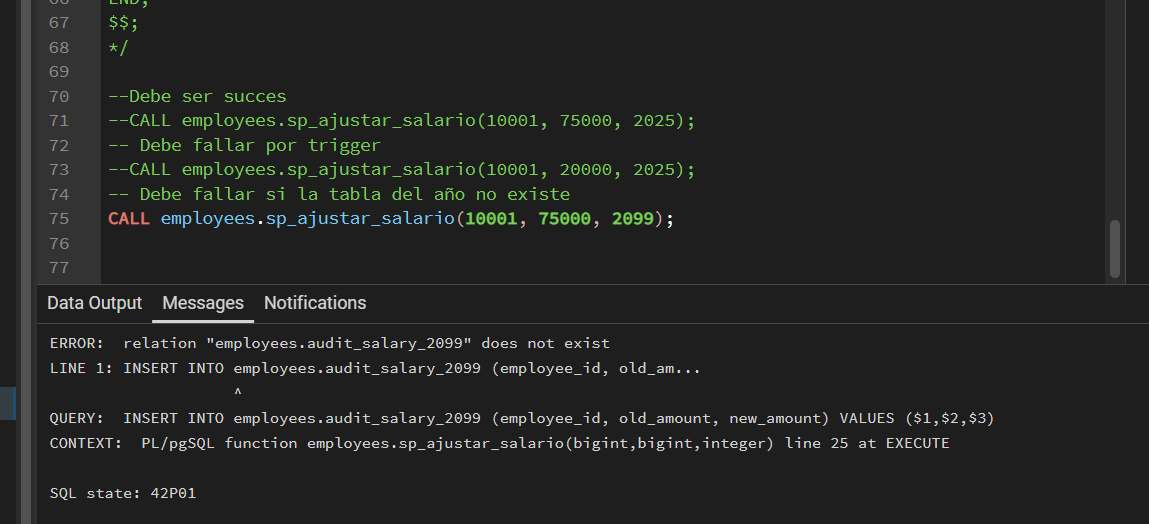
> Aqui el fallo es el esperado de la 3° ejecución


### Preguntas

- 1. Por que estamos trabjando con tablas dinamicas y postgresql para poder hace run insert debe saber el nombre de la tabla en tiempo de compilación, no de ejecución.
- 2. Bueno logicamente va a fallar, específicamente porque hemos establecido un trigger que lo que hace es que en el paso del INSERT previamente valide que el nuevo monto no sea menor a 30000, lo que lanzó el error finalmente
- 3. Bueno se ejecuta el tradicional ROLLBACK si es que falla la operación.

In [11]:
%pip install psycopg2 pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Parte 4

Código brindado:

In [3]:
import psycopg2
from psycopg2 import pool, sql, errors
# Configuren con sus credenciales
DB_CONFIG = {
"host": "localhost",
"port": 5555,
"dbname": "postgres",
"user": "postgres",
"password": "12345"
}
# Pool con mínimo 2 y máximo 10 conexiones
connection_pool = pool.ThreadedConnectionPool(
minconn=2,
maxconn=10,
**DB_CONFIG
)

### Pregunta 4.2

Código de solución:

In [8]:
def ajustar_salario(employee_id: int, nuevo_salario: int, thread_id: int):
    conn = connection_pool.getconn()
    try:
        conn.autocommit = False
        with conn.cursor() as cur:
            cur.execute(
                "CALL employees.sp_ajustar_salario(%s, %s, %s)",
                (employee_id, nuevo_salario, 2025)
            )
        conn.commit()
    except Exception as e:
        conn.rollback()
        print(f"Hilo {thread_id} error: {e}")
    finally:
        connection_pool.putconn(conn)

### Pregunta 4.3:

Código de solución:


In [14]:
import threading
import random

EMPLEADOS_PRUEBA = [10001, 10002, 10003, 10004, 10005]

def simular_ajustes_concurrentes(n_hilos=6):
    threads = []
    for i in range(n_hilos):
        emp = random.choice(EMPLEADOS_PRUEBA)
        salario = random.randint(20000, 80000)

        t = threading.Thread(
            target=ajustar_salario,
            args=(emp, salario, i)
        )
        threads.append(t)
        t.start()

    for t in threads:
        t.join()
        
simular_ajustes_concurrentes(n_hilos=6)

Hilo 0 error: Salario menor al mínimo permitido
CONTEXT:  PL/pgSQL function employees.fn_validar_salario() line 4 at RAISE
SQL statement "INSERT INTO employees.salary(employee_id, amount, from_date, to_date)
    VALUES (p_employee_id, p_nuevo_monto, CURRENT_DATE, '9999-01-01')"
PL/pgSQL function employees.sp_ajustar_salario(bigint,bigint,integer) line 19 at SQL statement

Hilo 1 error: duplicate key value violates unique constraint "idx_16991_primary"
DETAIL:  Key (employee_id, from_date)=(10003, 2026-03-27) already exists.
CONTEXT:  SQL statement "INSERT INTO employees.salary(employee_id, amount, from_date, to_date)
    VALUES (p_employee_id, p_nuevo_monto, CURRENT_DATE, '9999-01-01')"
PL/pgSQL function employees.sp_ajustar_salario(bigint,bigint,integer) line 19 at SQL statement

Hilo 4 error: Salario menor al mínimo permitido
CONTEXT:  PL/pgSQL function employees.fn_validar_salario() line 4 at RAISE
SQL statement "INSERT INTO employees.salary(employee_id, amount, from_date, to_date)


### Preguntas 

Código de la ejecución:

In [13]:
def ver_auditoria():    
    conn = connection_pool.getconn()
    try:
        with conn.cursor() as cur:
            cur.execute("""
            SELECT employee_id, old_amount, new_amount, changed_at
            FROM employees.audit_salary_2025
            ORDER BY changed_at DESC
            LIMIT 20;
            """)
            rows = cur.fetchall()
            cols = [desc[0] for desc in cur.description]
        import pandas as pd
        df = pd.DataFrame(rows, columns=cols)
        display(df)
    finally:
        connection_pool.putconn(conn)
        
ver_auditoria()

,employee_id,old_amount,new_amount,changed_at
0,10003,43311,61987,2026-03-27 22:19:40.050060+00:00
1,10002,72527,69941,2026-03-27 22:19:39.747614+00:00
2,10005,94692,48652,2026-03-27 22:19:39.747305+00:00
3,10001,88958,75000,2026-03-27 21:56:54.974511+00:00


- 1. Tendríamos un serio problema de prácticas básicas en las transacciones ya que el hecho de que no hay control de rollback, implaca que tengamos inconsistencia
        
2. Bueno tras la salida de la auditoria, no salió algún caso, o si hubiera algún error de ejcución serian salarios menores a 30000, pero en el caso de los hilos si detectamos algunos casos donde se buscaba insertar valores menores a 30000.
        
3. Nos permite reutilizar conexiones lo que a grandes pasos nos brinda un mejor rendimiento
        
4. Tras investigar notamos que PostgreSQL usa **locks (row-level locking)** y que nos ayuda a evitar la corrupción, se detecto Puede haber espera (blocking), se pudiera inferir en algunos casos cuando la transacción tarda más de lo esperado, ya que estaría en un lock, donde una transacción A usa la transacción B y la B debe esperar que A termine de usar el recurso en común.